### Required Modules

In [1]:
import os
import sys
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor

Local scripts:

In [2]:
project_root = os.path.abspath("..")
sys.path.append(project_root)

from models.custom_regression_tree import CustomRegressionTree as CRTree
from models.custom_random_forest import CustomRandomForest as CRForest

### Global Variables

In [3]:
# FILEPATH = os.path.join("..", "data", "Maternal_Health_Risk.csv")
FILEPATH = os.path.join("..", "data", "Student_Performance.csv")
SEED = 42
# LABEL = "RiskLevel"
LABEL = "Performance Index"

### Utility Methods

In [4]:
def model_version(name: str, params: dict) -> str:
    """Join model name with parameters"""
    parameters = str(params).replace(":", "=").replace(" ", "").replace("'", "")
    return name + '@' + parameters


def get_scores(label: np.array, prediction: np.array) -> dict:
    """Calculate model prediction scores"""
    rmse = np.sqrt(np.mean((prediction - label) ** 2))
    mape = np.mean(np.abs((label - prediction) / label)) * 100
    return {"RMSE": rmse, "MAPE": mape}


def get_parameters(s: str) -> dict:
    """Retrieves model parameters from string"""
    pattern = r'(\w+)=([^,]+)'
    parameters = dict(re.findall(pattern, s.strip("{}")))
    for k, v in parameters.items():
        if v.isdigit():
            parameters[k] = int(v)
        else:
            parameters[k] = float(v)
    return parameters

### Data Ingestion

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


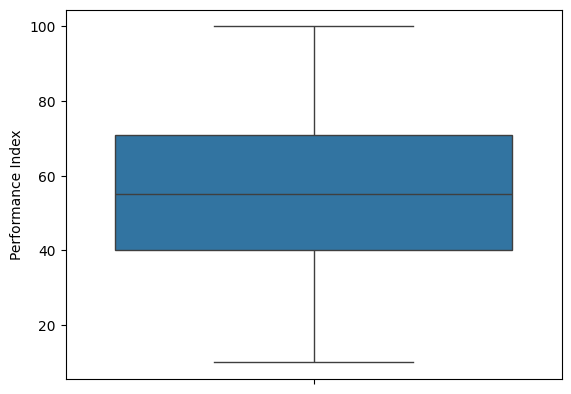

In [5]:
data = pd.read_csv(FILEPATH)

sns.boxplot(data[LABEL])

data.head()

## Modeling

Train and test (holdout) split:

In [6]:
df_trn, df_tst = train_test_split(
    data,
    train_size=0.7,
    shuffle=True,
    random_state=SEED)

df_trn.shape, df_tst.shape

((7000, 6), (3000, 6))

### Define Hyperparameters

In [7]:
max_depth = [3, 6, 12, 24]
min_samples_split = [2, 4, 8, 16]
n_trees = [50]
alpha = [0.01, 0.1, 1.0, 10.0]


tree_param_grid = [
    { "max_depth": mxd, "min_samples_split": mss }
    for mxd in max_depth
    for mss in min_samples_split
]

sklearn_tree_param_grid = [
    {
        "max_depth": mxd,
        "min_samples_split": mss,
        "random_state": SEED
    }
    for mxd in max_depth
    for mss in min_samples_split
]

forest_param_grid = [
    { "n_trees": ntr, "max_depth": mxd, "min_samples_split": mss }
    for ntr in n_trees
    for mxd in max_depth
    for mss in min_samples_split
]

sklearn_forest_param_grid = [
    {
        "max_depth": mxd,
        "min_samples_split": mss,
        "n_estimators": 50,
        "random_state": SEED
    }
    for mxd in max_depth
    for mss in min_samples_split
]

sklearn_linear_param_grid = [
    {
        "alpha": alp,
        "max_iter": 10000,
        "random_state": SEED
    }
    for alp in alpha
]


models_to_run = {
    "CustomRegressionTree": (CRTree, tree_param_grid),
    "SklearnRegressionTree": (DecisionTreeRegressor, sklearn_tree_param_grid),
    "CustomRandomForest": (CRForest, forest_param_grid),
    "SklearnRandomForest": (RandomForestRegressor, sklearn_forest_param_grid),
    "LassoRegression": (Lasso, sklearn_linear_param_grid)}

### Cross-Validation

In [8]:
kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

features = [c for c in df_trn if c != LABEL]
numeric_features = df_trn[features].select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in features if c not in numeric_features]

model_scores = {}
for indexes_trn, indexes_vln in kf.split(df_trn):

    X_trn_raw = df_trn.iloc[indexes_trn][features]
    X_vln_raw = df_trn.iloc[indexes_vln][features]

    y = df_trn[LABEL].values
    y_trn, y_vln = y[indexes_trn], y[indexes_vln]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                categorical_features),
            (
                "num",
                StandardScaler(),
                numeric_features)])

    X_trn = preprocessor.fit_transform(X_trn_raw)
    X_vln = preprocessor.fit_transform(X_vln_raw)


    for name in models_to_run:
        regressor, parameter_grid = models_to_run[name]
        for params in parameter_grid:

            version = model_version(name, params)
            if version not in model_scores.keys():
                model_scores[version] = {"RMSE": [], "MAPE": []}

            model = regressor(**params)
            model.fit(X_trn, y_trn)
            prediction = model.predict(X_vln)

            metrics = get_scores(y_vln, prediction)
            model_scores[version]["RMSE"].append(metrics["RMSE"])
            model_scores[version]["MAPE"].append(metrics["MAPE"])

### Generate Plots

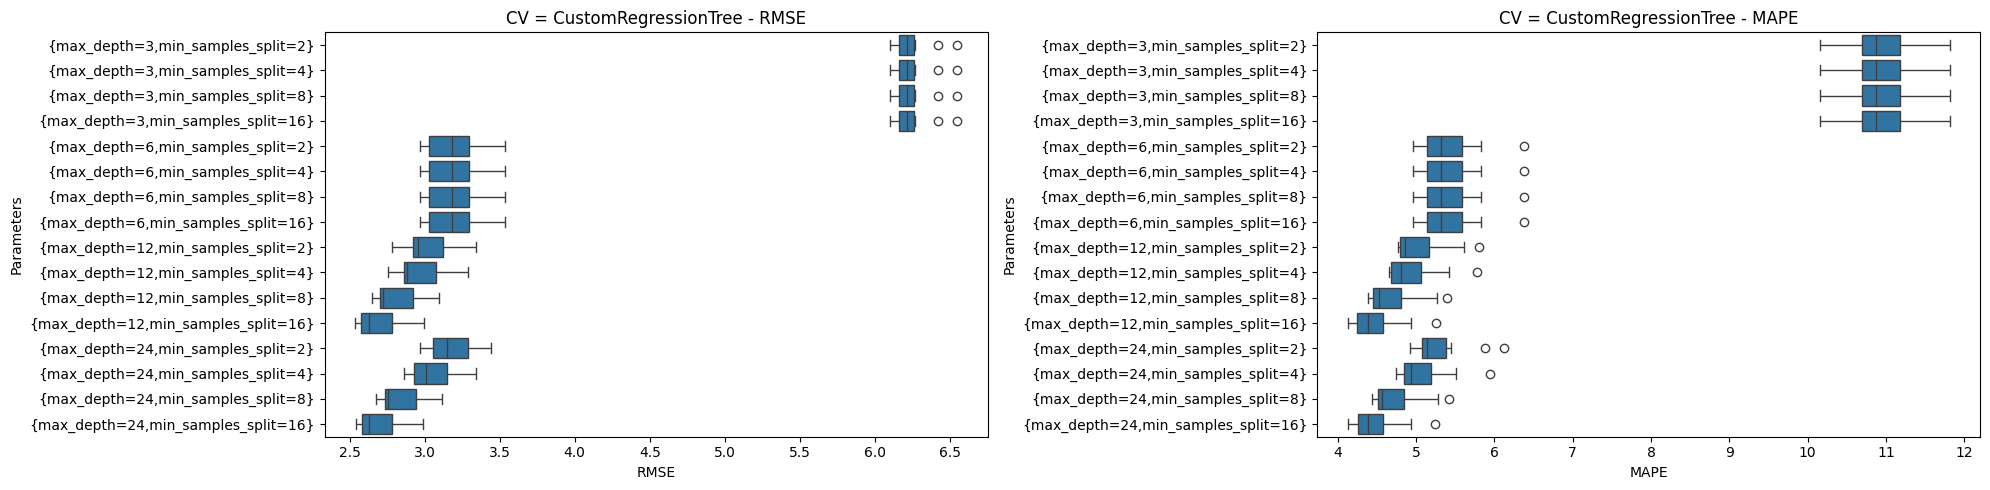

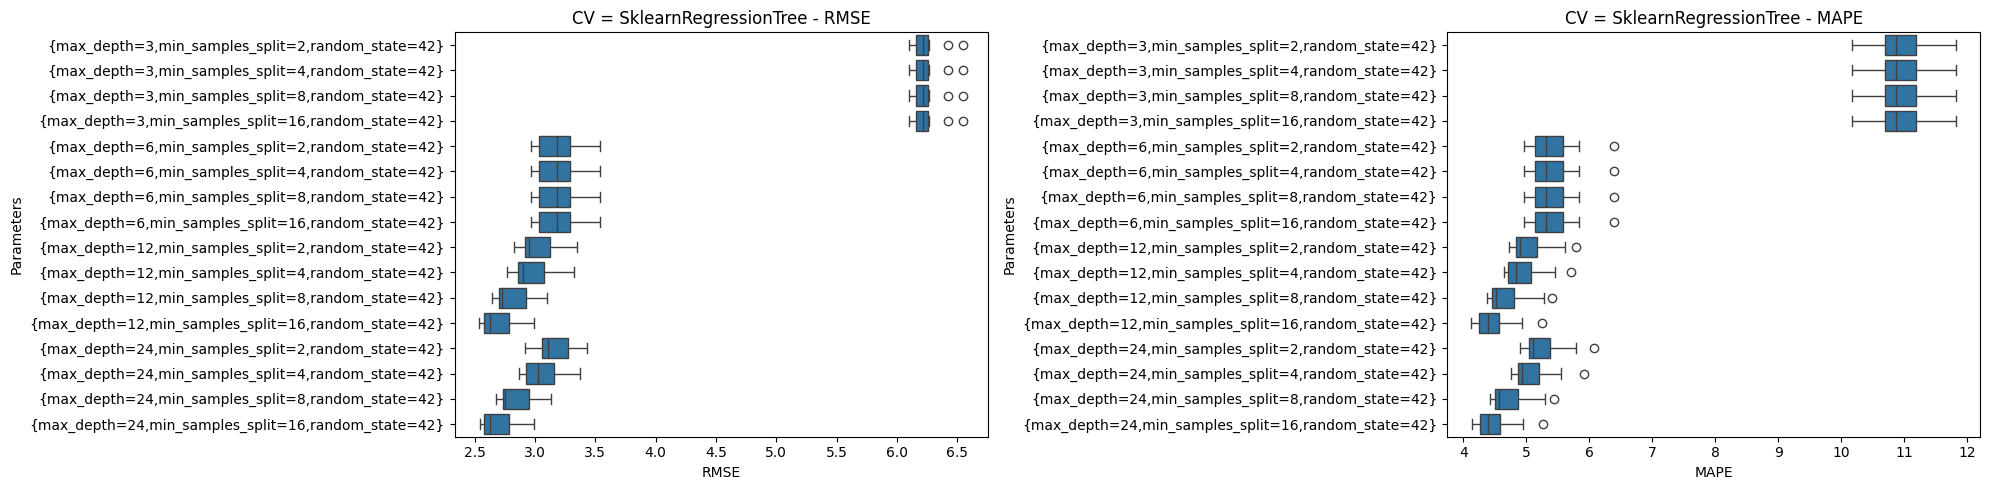

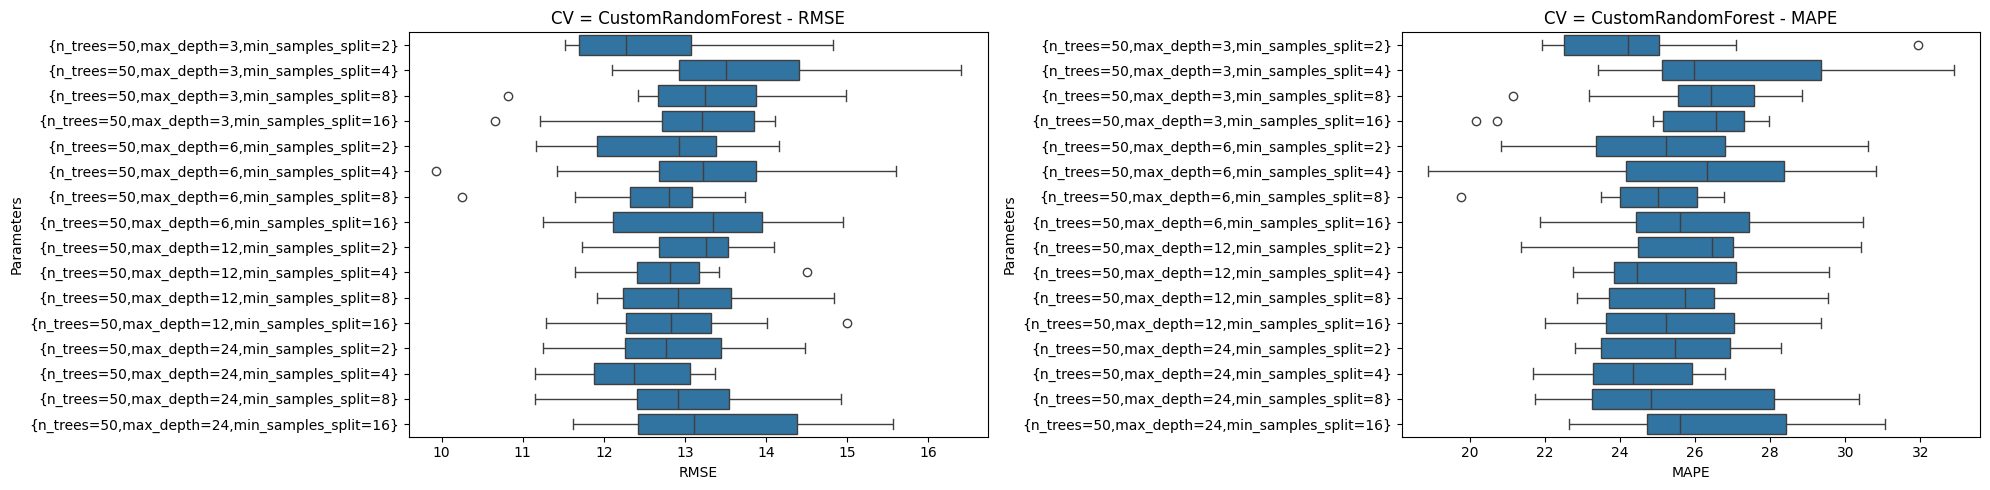

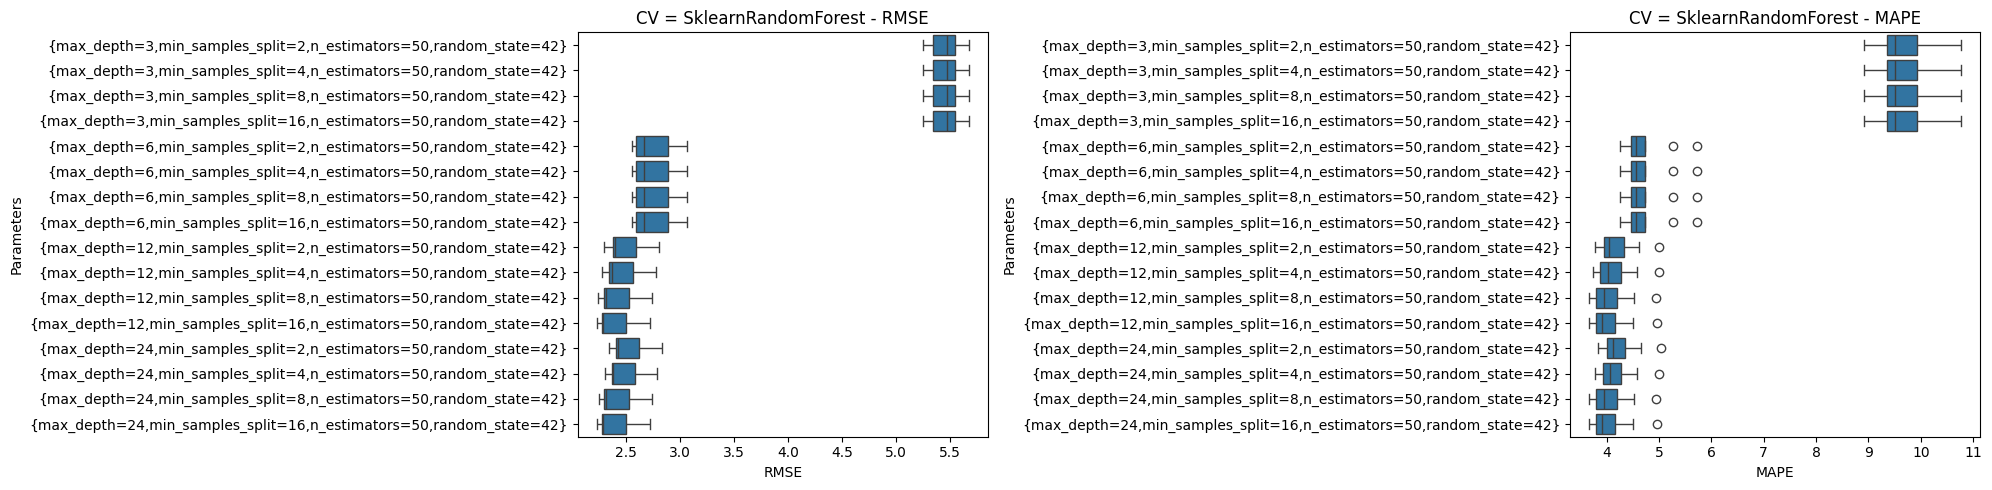

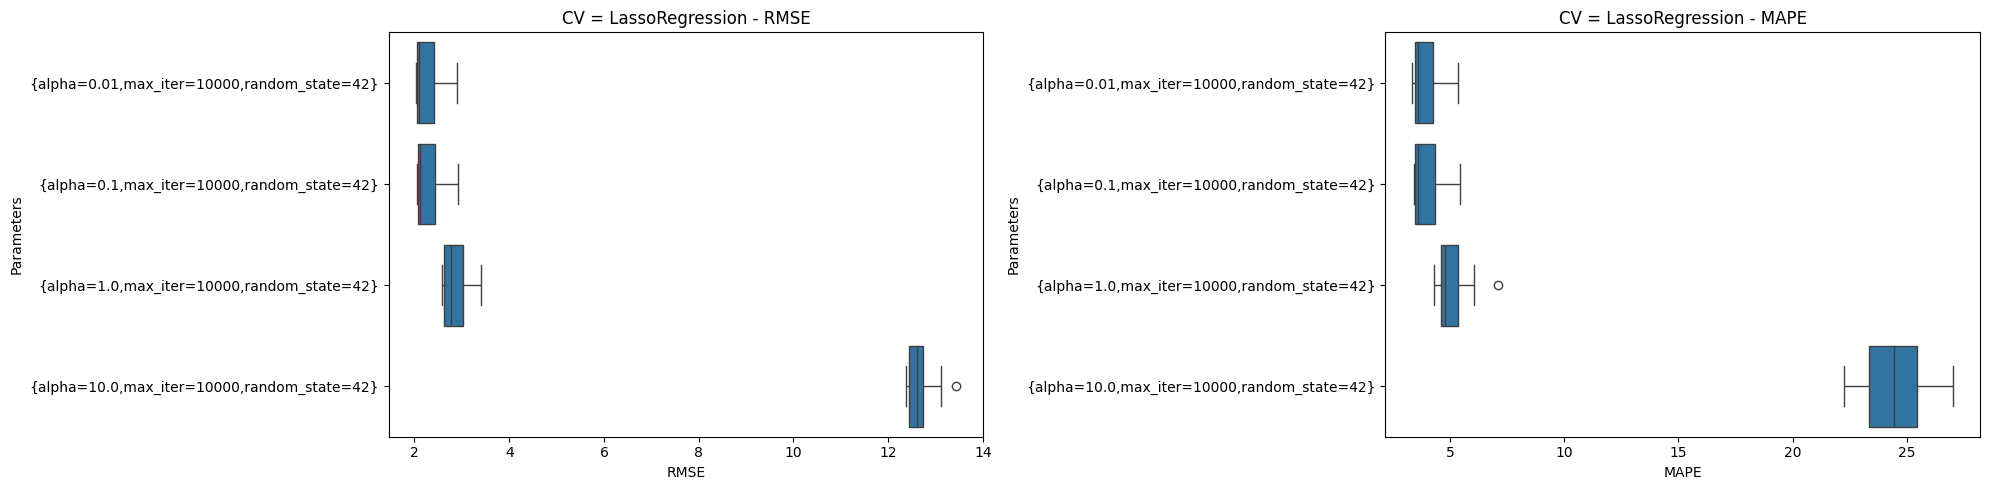

In [9]:
results = []

for name in models_to_run:
    model_data = []

    for version, scores in model_scores.items():
        if name in version:

            _, params_str = version.split("@")

            for metric, score in scores.items():
                part = pd.DataFrame([
                    {
                        "MODEL": name,
                        "PARAMS": params_str,
                        "METRIC": metric,
                        "FOLD": fold,
                        "VALUES": values}
                    for fold, values in enumerate(score)])
                params_dict = part["PARAMS"].apply(
                    lambda s: dict(re.findall(r"([^={},\s]+)=([^={},\s]+)", s))).copy()
                part = part.join(params_dict.apply(pd.Series))
                model_data.append(part)

    detail = pd.concat(model_data)
    
    if "max_depth" in detail.columns:
        detail["max_depth"] = detail["max_depth"].astype(int)

    if "min_samples_split" in detail.columns:
        detail["min_samples_split"] = detail["min_samples_split"].astype(int)

    if "alpha" in detail.columns:
        detail["alpha"] = detail["alpha"].astype(float)

    metrics = detail["METRIC"].unique()
    fig, axes = plt.subplots(1, 2, figsize=(20, 5))

    for i, metric in enumerate(metrics):
        detail_metric = detail[detail["METRIC"] == metric]
        sns.boxplot(data=detail_metric, x="VALUES", y="PARAMS", ax=axes[i])
        axes[i].set_ylabel("Parameters")
        axes[i].set_xlabel(metric)
        axes[i].title.set_text(f"CV = {name} - {metric}")
    plt.tight_layout()

    results.append(
        detail.groupby(
            ["MODEL", "PARAMS", "METRIC"])["VALUES"].agg(
                ["mean", "min", "max", "std"]).copy())

In [10]:
result_ranking = pd.concat(results).reset_index()
result_ranking["SCORE"] = result_ranking["mean"] + result_ranking["std"]
best_parameters = {}

for name in models_to_run:
    model_experiments = (result_ranking["MODEL"] == name)
    model_ranking = result_ranking[model_experiments].sort_values(by="SCORE")

    best_row = model_ranking.loc[model_ranking["SCORE"].idxmin()]
    best_parameters[name] = get_parameters(best_row["PARAMS"])

    display(
        model_ranking.pivot(
            index=["MODEL", "PARAMS"],
            columns="METRIC").sort_values(
                ("SCORE", "RMSE"),
                ascending=True))

mean            \
METRIC                                                         MAPE      RMSE   
MODEL                PARAMS                                                     
CustomRegressionTree {max_depth=24,min_samples_split=16}   4.493810  2.686941   
                     {max_depth=12,min_samples_split=16}   4.492009  2.685500   
                     {max_depth=12,min_samples_split=8}    4.700937  2.804574   
                     {max_depth=24,min_samples_split=8}    4.732613  2.832677   
                     {max_depth=12,min_samples_split=4}    4.955270  2.957601   
                     {max_depth=12,min_samples_split=2}    5.046335  3.015374   
                     {max_depth=24,min_samples_split=4}    5.093170  3.046548   
                     {max_depth=24,min_samples_split=2}    5.304375  3.175274   
                     {max_depth=6,min_samples_split=8}     5.422448  3.192869   
                     {max_depth=6,min_samples_split=4}     5.422448  3.192869   
                     {max_depth=6,min_samples_split=2}     5.422448  3.192869   
                     {max_depth=6,min_samples_split=16}    5.422448  3.192869   
                     {max_depth=3,min_samples_split=8}    10.930198  6.246594   
                     {max_depth=3,min_samples_split=4}    10.930198  6.246594   
                     {max_depth=3,min_samples_split=2}    10.930198  6.246594   
                     {max_depth=3,min_samples_split=16}   10.930198  6.246594   

                                                                min            \
METRIC                                                         MAPE      RMSE   
MODEL                PARAMS                                                     
CustomRegressionTree {max_depth=24,min_samples_split=16}   4.138510  2.546118   
                     {max_depth=12,min_samples_split=16}   4.126555  2.536551   
                     {max_depth=12,min_samples_split=8}    4.394020  2.648316   
                     {max_depth=24,min_samples_split=8}    4.442100  2.676414   
                     {max_depth=12,min_samples_split=4}    4.661447  2.755932   
                     {max_depth=12,min_samples_split=2}    4.769074  2.780224   
                     {max_depth=24,min_samples_split=4}    4.749620  2.865801   
                     {max_depth=24,min_samples_split=2}    4.927016  2.971191   
                     {max_depth=6,min_samples_split=8}     4.964107  2.967058   
                     {max_depth=6,min_samples_split=4}     4.964107  2.967058   
                     {max_depth=6,min_samples_split=2}     4.964107  2.967058   
                     {max_depth=6,min_samples_split=16}    4.964107  2.967058   
                     {max_depth=3,min_samples_split=8}    10.160644  6.100969   
                     {max_depth=3,min_samples_split=4}    10.160644  6.100969   
                     {max_depth=3,min_samples_split=2}    10.160644  6.100969   
                     {max_depth=3,min_samples_split=16}   10.160644  6.100969   

                                                                max            \
METRIC                                                         MAPE      RMSE   
MODEL                PARAMS                                                     
CustomRegressionTree {max_depth=24,min_samples_split=16}   5.245213  2.991959   
                     {max_depth=12,min_samples_split=16}   5.254059  2.994621   
                     {max_depth=12,min_samples_split=8}    5.391999  3.093829   
                     {max_depth=24,min_samples_split=8}    5.424519  3.115121   
                     {max_depth=12,min_samples_split=4}    5.773969  3.288618   
                     {max_depth=12,min_samples_split=2}    5.809254  3.343853   
                     {max_depth=24,min_samples_split=4}    5.940528  3.341763   
                     {max_depth=24,min_samples_split=2}    6.119363  3.444250   
                     {max_depth=6,min_samples_split=8}     6.382464  3.536621   
           

mean  \
METRIC                                                                         MAPE   
MODEL                 PARAMS                                                          
SklearnRegressionTree {max_depth=12,min_samples_split=16,random_state...   4.487183   
                      {max_depth=24,min_samples_split=16,random_state...   4.495165   
                      {max_depth=12,min_samples_split=8,random_state=42}   4.699353   
                      {max_depth=24,min_samples_split=8,random_state=42}   4.733688   
                      {max_depth=12,min_samples_split=4,random_state=42}   4.963375   
                      {max_depth=12,min_samples_split=2,random_state=42}   5.051842   
                      {max_depth=24,min_samples_split=4,random_state=42}   5.098476   
                      {max_depth=24,min_samples_split=2,random_state=42}   5.259350   
                      {max_depth=6,min_samples_split=8,random_state=42}    5.422448   
                      {max_depth=6,min_samples_split=4,random_state=42}    5.422448   
                      {max_depth=6,min_samples_split=2,random_state=42}    5.422448   
                      {max_depth=6,min_samples_split=16,random_state=42}   5.422448   
                      {max_depth=3,min_samples_split=8,random_state=42}   10.930198   
                      {max_depth=3,min_samples_split=4,random_state=42}   10.930198   
                      {max_depth=3,min_samples_split=2,random_state=42}   10.930198   
                      {max_depth=3,min_samples_split=16,random_state=42}  10.930198   

                                                                                    \
METRIC                                                                        RMSE   
MODEL                 PARAMS                                                         
SklearnRegressionTree {max_depth=12,min_samples_split=16,random_state...  2.684070   
                      {max_depth=24,min_samples_split=16,random_state...  2.687855   
                      {max_depth=12,min_samples_split=8,random_state=42}  2.806547   
                      {max_depth=24,min_samples_split=8,random_state=42}  2.837109   
                      {max_depth=12,min_samples_split=4,random_state=42}  2.966024   
                      {max_depth=12,min_samples_split=2,random_state=42}  3.017635   
                      {max_depth=24,min_samples_split=4,random_state=42}  3.054856   
                      {max_depth=24,min_samples_split=2,random_state=42}  3.152991   
                      {max_depth=6,min_samples_split=8,random_state=42}   3.192869   
                      {max_depth=6,min_samples_split=4,random_state=42}   3.192869   
                      {max_depth=6,min_samples_split=2,random_state=42}   3.192869   
                      {max_depth=6,min_samples_split=16,random_state=42}  3.192869   
                      {max_depth=3,min_samples_split=8,random_state=42}   6.246594   
                      {max_depth=3,min_samples_split=4,random_state=42}   6.246594   
                      {max_depth=3,min_samples_split=2,random_state=42}   6.246594   
                      {max_depth=3,min_samples_split=16,random_state=42}  6.246594   

                                                                                min  \
METRIC                                                                         MAPE   
MODEL                 PARAMS                                                          
SklearnRegressionTree {max_depth=12,min_samples_split=16,random_state...   4.126555   
                      {max_depth=24,min_samples_split=16,random_state...   4.138510   
                      {max_depth=12,min_samples_split=8,random_state=42}   4.375979   
                      {max_depth=24,min_samples_split=8,random_state=42}   4.425740   
                      {max_depth=12,min_samples_split=4,random_state=42}   4.648895   
                      {max_depth=12,min_samples_split=2,random_state=42}   4.723255   
       

mean  \
METRIC                                                                  MAPE   
MODEL              PARAMS                                                      
CustomRandomForest {n_trees=50,max_depth=24,min_samples_split=4}   24.458409   
                   {n_trees=50,max_depth=6,min_samples_split=8}    24.675938   
                   {n_trees=50,max_depth=3,min_samples_split=2}    24.648663   
                   {n_trees=50,max_depth=12,min_samples_split=4}   25.382043   
                   {n_trees=50,max_depth=12,min_samples_split=2}   25.880360   
                   {n_trees=50,max_depth=6,min_samples_split=2}    25.105214   
                   {n_trees=50,max_depth=24,min_samples_split=2}   25.359961   
                   {n_trees=50,max_depth=12,min_samples_split=8}   25.654545   
                   {n_trees=50,max_depth=12,min_samples_split=16}  25.441675   
                   {n_trees=50,max_depth=24,min_samples_split=8}   25.557894   
                   {n_trees=50,max_depth=3,min_samples_split=16}   25.477568   
                   {n_trees=50,max_depth=6,min_samples_split=16}   25.868450   
                   {n_trees=50,max_depth=3,min_samples_split=8}    25.998154   
                   {n_trees=50,max_depth=6,min_samples_split=4}    25.819603   
                   {n_trees=50,max_depth=24,min_samples_split=16}  26.306794   
                   {n_trees=50,max_depth=3,min_samples_split=4}    27.152931   

                                                                              \
METRIC                                                                  RMSE   
MODEL              PARAMS                                                      
CustomRandomForest {n_trees=50,max_depth=24,min_samples_split=4}   12.421561   
                   {n_trees=50,max_depth=6,min_samples_split=8}    12.533882   
                   {n_trees=50,max_depth=3,min_samples_split=2}    12.525661   
                   {n_trees=50,max_depth=12,min_samples_split=4}   12.861148   
                   {n_trees=50,max_depth=12,min_samples_split=2}   13.100028   
                   {n_trees=50,max_depth=6,min_samples_split=2}    12.745077   
                   {n_trees=50,max_depth=24,min_samples_split=2}   12.876989   
                   {n_trees=50,max_depth=12,min_samples_split=8}   13.002612   
                   {n_trees=50,max_depth=12,min_samples_split=16}  12.895730   
                   {n_trees=50,max_depth=24,min_samples_split=8}   12.951542   
                   {n_trees=50,max_depth=3,min_samples_split=16}   12.948245   
                   {n_trees=50,max_depth=6,min_samples_split=16}   13.111560   
                   {n_trees=50,max_depth=3,min_samples_split=8}    13.218347   
                   {n_trees=50,max_depth=6,min_samples_split=4}    13.071508   
                   {n_trees=50,max_depth=24,min_samples_split=16}  13.325099   
                   {n_trees=50,max_depth=3,min_samples_split=4}    13.753270   

                                                                         min  \
METRIC                                                                  MAPE   
MODEL              PARAMS                                                      
CustomRandomForest {n_trees=50,max_depth=24,min_samples_split=4}   21.661503   
                   {n_trees=50,max_depth=6,min_samples_split=8}    19.747001   
                   {n_trees=50,max_depth=3,min_samples_split=2}    21.922375   
                   {n_trees=50,max_depth=12,min_samples_split=4}   22.730411   
                   {n_trees=50,max_depth=12,min_samples_split=2}   21.349316   
                   {n_trees=50,max_depth=6,min_samples_split=2}    20.830295   
                   {n_trees=50,max_depth=24,min_samples_split=2}   22.798618   
                   {n_trees=50,max_depth=12,min_samples_split=8}   22.845599   
                   {n_trees=50,max_depth=12,min_samples_split=16}  21.988219   
                   {n_trees=50,max_depth=24,min_samples_split=8}   21.

mean  \
METRIC                                                                      MAPE   
MODEL               PARAMS                                                         
SklearnRandomForest {max_depth=24,min_samples_split=16,n_estimators...  4.057161   
                    {max_depth=12,min_samples_split=16,n_estimators...  4.057782   
                    {max_depth=12,min_samples_split=8,n_estimators=...  4.070604   
                    {max_depth=24,min_samples_split=8,n_estimators=...  4.071812   
                    {max_depth=12,min_samples_split=4,n_estimators=...  4.141832   
                    {max_depth=24,min_samples_split=4,n_estimators=...  4.165014   
                    {max_depth=12,min_samples_split=2,n_estimators=...  4.182620   
                    {max_depth=24,min_samples_split=2,n_estimators=...  4.235228   
                    {max_depth=6,min_samples_split=8,n_estimators=5...  4.712200   
                    {max_depth=6,min_samples_split=4,n_estimators=5...  4.712200   
                    {max_depth=6,min_samples_split=2,n_estimators=5...  4.712200   
                    {max_depth=6,min_samples_split=16,n_estimators=...  4.712200   
                    {max_depth=3,min_samples_split=8,n_estimators=5...  9.653160   
                    {max_depth=3,min_samples_split=4,n_estimators=5...  9.653160   
                    {max_depth=3,min_samples_split=2,n_estimators=5...  9.653160   
                    {max_depth=3,min_samples_split=16,n_estimators=...  9.653160   

                                                                                  \
METRIC                                                                      RMSE   
MODEL               PARAMS                                                         
SklearnRandomForest {max_depth=24,min_samples_split=16,n_estimators...  2.391486   
                    {max_depth=12,min_samples_split=16,n_estimators...  2.391830   
                    {max_depth=12,min_samples_split=8,n_estimators=...  2.413275   
                    {max_depth=24,min_samples_split=8,n_estimators=...  2.415778   
                    {max_depth=12,min_samples_split=4,n_estimators=...  2.457119   
                    {max_depth=24,min_samples_split=4,n_estimators=...  2.473456   
                    {max_depth=12,min_samples_split=2,n_estimators=...  2.479479   
                    {max_depth=24,min_samples_split=2,n_estimators=...  2.513579   
                    {max_depth=6,min_samples_split=8,n_estimators=5...  2.742943   
                    {max_depth=6,min_samples_split=4,n_estimators=5...  2.742943   
                    {max_depth=6,min_samples_split=2,n_estimators=5...  2.742943   
                    {max_depth=6,min_samples_split=16,n_estimators=...  2.742943   
                    {max_depth=3,min_samples_split=8,n_estimators=5...  5.449664   
                    {max_depth=3,min_samples_split=4,n_estimators=5...  5.449664   
                    {max_depth=3,min_samples_split=2,n_estimators=5...  5.449664   
                    {max_depth=3,min_samples_split=16,n_estimators=...  5.449664   

                                                                             min  \
METRIC                                                                      MAPE   
MODEL               PARAMS                                                         
SklearnRandomForest {max_depth=24,min_samples_split=16,n_estimators...  3.670753   
                    {max_depth=12,min_samples_split=16,n_estimators...  3.672482   
                    {max_depth=12,min_samples_split=8,n_estimators=...  3.664661   
                    {max_depth=24,min_samples_split=8,n_estimators=...  3.670391   
                    {max_depth=12,min_samples_split=4,n_estimators=...  3.741775   
                    {max_depth=24,min_samples_split=4,n_estimators=...  3.774045   
                    {max_depth=12,min_samples_split=2,n_estimators=...  3.769313   
                    {max_depth=24,min_samp

mean  \
METRIC                                                            MAPE   
MODEL           PARAMS                                                   
LassoRegression {alpha=0.01,max_iter=10000,random_state=42}   3.898445   
                {alpha=0.1,max_iter=10000,random_state=42}    3.947405   
                {alpha=1.0,max_iter=10000,random_state=42}    5.116945   
                {alpha=10.0,max_iter=10000,random_state=42}  24.560194   

                                                                        \
METRIC                                                            RMSE   
MODEL           PARAMS                                                   
LassoRegression {alpha=0.01,max_iter=10000,random_state=42}   2.280570   
                {alpha=0.1,max_iter=10000,random_state=42}    2.299196   
                {alpha=1.0,max_iter=10000,random_state=42}    2.869699   
                {alpha=10.0,max_iter=10000,random_state=42}  12.688921   

                                                                   min  \
METRIC                                                            MAPE   
MODEL           PARAMS                                                   
LassoRegression {alpha=0.01,max_iter=10000,random_state=42}   3.361177   
                {alpha=0.1,max_iter=10000,random_state=42}    3.428890   
                {alpha=1.0,max_iter=10000,random_state=42}    4.288847   
                {alpha=10.0,max_iter=10000,random_state=42}  22.262515   

                                                                        \
METRIC                                                            RMSE   
MODEL           PARAMS                                                   
LassoRegression {alpha=0.01,max_iter=10000,random_state=42}   2.027956   
                {alpha=0.1,max_iter=10000,random_state=42}    2.059290   
                {alpha=1.0,max_iter=10000,random_state=42}    2.575444   
                {alpha=10.0,max_iter=10000,random_state=42}  12.370267   

                                                                   max  \
METRIC                                                            MAPE   
MODEL           PARAMS                                                   
LassoRegression {alpha=0.01,max_iter=10000,random_state=42}   5.343513   
                {alpha=0.1,max_iter=10000,random_state=42}    5.453951   
                {alpha=1.0,max_iter=10000,random_state=42}    7.089236   
                {alpha=10.0,max_iter=10000,random_state=42}  27.010039   

                                                                        \
METRIC                                                            RMSE   
MODEL           PARAMS                                                   
LassoRegression {alpha=0.01,max_iter=10000,random_state=42}   2.896000   
                {alpha=0.1,max_iter=10000,random_state=42}    2.923993   
                {alpha=1.0,max_iter=10000,random_state=42}    3.397522   
                {alpha=10.0,max_iter=10000,random_state=42}  13.441310   

                                                                  std  \
METRIC                                                           MAPE   
MODEL           PARAMS                                                  
LassoRegression {alpha=0.01,max_iter=10000,random_state=42}  0.680931   
                {alpha=0.1,max_iter=10000,random_state=42}   0.693204   
                {alpha=1.0,max_iter=10000,random_state=42}   0.870027   
                {alpha=10.0,max_iter=10000,random_state=42}  1.569312   

                                                                       \
METRIC                                                           RMSE   
MODEL           PARAMS                                                  
LassoRegression {alpha=0.01,max_iter=10000,random_state=42}  0.329598   
                {alpha=0.1,max_iter=10000,random_state=42}   0.332166   
                {alpha=1.0,max_iter=10000,random_state=42}   0.300733   
  

### Holdout Performance

In [11]:
features = [c for c in df_trn if c != LABEL]
numeric_features = df_trn[features].select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in features if c not in numeric_features]

X_trn_raw = df_trn[features]
X_tst_raw = df_tst[features]

y_trn = df_trn[LABEL].values
y_tst = df_tst[LABEL].values

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features),
        (
            "num",
            StandardScaler(),
            numeric_features)])

X_trn = preprocessor.fit_transform(X_trn_raw)
X_tst = preprocessor.fit_transform(X_tst_raw)

test_scores = {}
for name, params in best_parameters.items():
    
    regressor = models_to_run[name][0]
    model = regressor(**params)
    model.fit(X_trn, y_trn)
    prediction = model.predict(X_tst)
    test_scores[name] = get_scores(y_tst, prediction)
    print(name, test_scores[name])

CustomRegressionTree {'RMSE': np.float64(2.694510212091909), 'MAPE': np.float64(4.782213650546748)}
SklearnRegressionTree {'RMSE': np.float64(2.695834904591947), 'MAPE': np.float64(4.78326511325038)}
CustomRandomForest {'RMSE': np.float64(13.012777310324731), 'MAPE': np.float64(26.921304031562794)}
SklearnRandomForest {'RMSE': np.float64(2.4694305936919014), 'MAPE': np.float64(4.401179692345933)}
LassoRegression {'RMSE': np.float64(2.1034621553120507), 'MAPE': np.float64(3.726147235404511)}


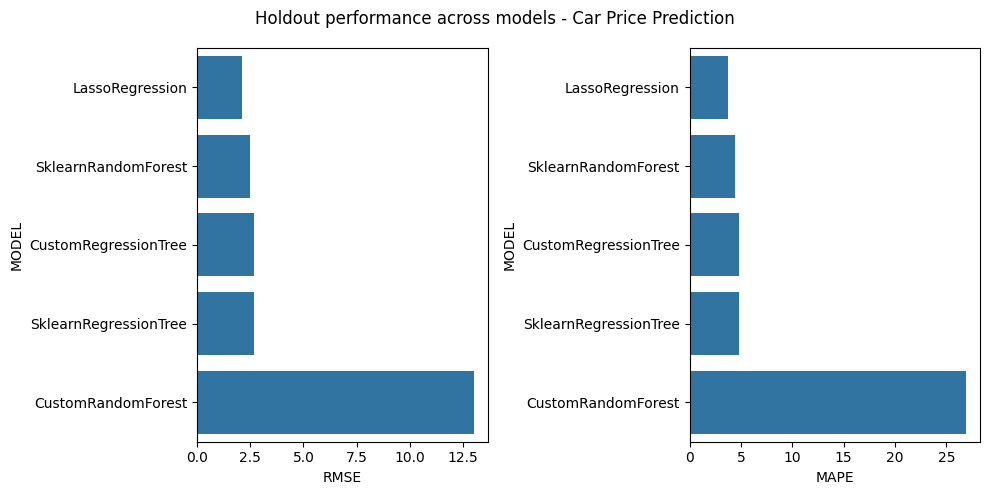

In [12]:
test_performance = pd.DataFrame([
    {"MODEL": name, "RMSE": test_scores[name]["RMSE"], "MAPE": test_scores[name]["MAPE"]}
    for name in test_scores
])
test_performance = test_performance.sort_values(by="RMSE")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.barplot(data=test_performance, y="MODEL", x="RMSE", ax=axes[0])
sns.barplot(data=test_performance, y="MODEL", x="MAPE", ax=axes[1])
plt.suptitle("Holdout performance across models - Car Price Prediction")
plt.tight_layout()

by [Manuel Velarde](mailto:manuel@velarde.me)